In [58]:
import numpy as np
from importlib import reload
import simulate_data as sim
reload(sim)
from gwas import gwas_linear, gwas_probit
from scipy.stats import norm

n, d = 5_000, 200
k = 10
corr = 0.7
rho = 0.7
snr_s = 2
snr_y = 1
pi_s = 0.1
pi_y = 0.05
p_sel = 0.3
rng = np.random.default_rng(42)

# LD matrix
R = sim.simulate_block_correlation_matrix(d, k, corr)

X = sim.simulate_design_matrix(n, R, intercept = False, rng = rng)

beta_s = sim.beta_s(d, R, pi_s, snr_s, rng)
beta_y, sigma2_y = sim.beta_heckman(d, R, pi_y, snr_y, rng)

s, y, s_star, y_star =  sim.heckman_outcome(X, beta_s, beta_y, sigma2_y, p_sel, rho, snr_s, rng = rng)

z_s, a_s = gwas_probit(X, s)[0:2] 
b_s = z_s / np.sqrt(len(s))

In [66]:
import numpy as np
from scipy.stats import norm
from sklearn.linear_model import LogisticRegression

def z_scores_no_ascertainment(X, s, C=None):
    """PCGC-s z-scores for a random (non-ascertained) sample.

    X: (n, m) genotypes standardized with reference-panel allele frequencies.
    s: (n,) binary phenotype (1 = case).
    C: optional (n, q) covariates (without intercept).
    Returns z (m,) and the per-individual weight vector (None without covariates).
    """
    n, m = X.shape
    s = np.asarray(s, float)
    if C is None:
        P = s.mean()                                    # sample proportion, ~ K without ascertainment
        y_t = (s - P) / np.sqrt(P * (1 - P))
        z = X.T @ y_t / np.sqrt(n)                      # z_k = n^{-1/2} sum_i y_i X_ki
        tau = norm.ppf(1 - P)
        f = norm.pdf(tau) ** 2 / (P * (1 - P))          # f for P = K
        print(f"n={n}, m={m}, P={P:.4f}, f={f:.4g}")    # log basic diagnostics
        return z, None

    # covariates: P_i from logistic regression (first stage of PCGC)
    lr = LogisticRegression(penalty=None, max_iter=1000).fit(C, s)
    P_i = lr.predict_proba(C)[:, 1]
    tau_i = norm.ppf(1 - P_i)                           # K_i = P_i without ascertainment
    y_t = (s - P_i) / np.sqrt(P_i * (1 - P_i))
    w = norm.pdf(tau_i) / np.sqrt(P_i * (1 - P_i))      # sum_a u_a^i
    z = X.T @ (y_t * w)                                 # z_k^{covar}, no 1/sqrt(n) factor
    print(f"n={n}, m={m}, P_i range=[{P_i.min():.4f}, {P_i.max():.4f}]")
    return z, w

z, w = z_scores_no_ascertainment(X, s)

n=5000, m=200, P=0.3038, f=0.5781


In [91]:
snr_s = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 1, 2, 3, 4]
rng_seed = [i for i in range(5)]

results = []

for snr in snr_s:
    print(f"snr: {snr}")
    for seed in rng_seed:
        rng = np.random.default_rng(seed)
        
        beta_s = sim.beta_s(d, R, pi_s, snr, rng)
        
        s, y, s_star, y_star =  sim.heckman_outcome(X, beta_s, beta_y, sigma2_y, p_sel, rho, snr, rng = rng)
        
        z_s, a_s = gwas_probit(X, s)[0:2] 
        z, w = z_scores_no_ascertainment(X, s)
        
        h2_obs = estimate_h2_obs_HE(X, s)
        h2_liability = obs_to_liability_h2(h2_obs, p_sel)
    
        h2_pcgc =pcgc_h2_liability(z_s, R, n, p_sel)
        h2_pcgc2 =pcgc_h2_liability(z, R, n, p_sel)
    
        #print(f"snr: {snr}")
        #print(f"h2 HE: {h2_liability}, snr HE: {h2_to_snr(h2_liability)}")
        #print(f"h2 PCGC: {h2_pcgc}, snr PCGC: {h2_to_snr(h2_pcgc)}")

        results.append((snr, h2_to_snr(h2_liability), h2_to_snr(h2_pcgc), h2_to_snr(h2_pcgc2)))

snr: 0
n=5000, m=200, P=0.2984, f=0.5746
n=5000, m=200, P=0.3012, f=0.5764
n=5000, m=200, P=0.2960, f=0.5731
n=5000, m=200, P=0.3020, f=0.5769
n=5000, m=200, P=0.2906, f=0.5695
snr: 0.1
n=5000, m=200, P=0.2992, f=0.5752
n=5000, m=200, P=0.3004, f=0.5759
n=5000, m=200, P=0.2942, f=0.5719
n=5000, m=200, P=0.2996, f=0.5754
n=5000, m=200, P=0.2930, f=0.5711
snr: 0.2
n=5000, m=200, P=0.2986, f=0.5748
n=5000, m=200, P=0.3010, f=0.5763
n=5000, m=200, P=0.2922, f=0.5706
n=5000, m=200, P=0.2980, f=0.5744
n=5000, m=200, P=0.2960, f=0.5731
snr: 0.3
n=5000, m=200, P=0.2974, f=0.574
n=5000, m=200, P=0.3010, f=0.5763
n=5000, m=200, P=0.2918, f=0.5703
n=5000, m=200, P=0.2990, f=0.575
n=5000, m=200, P=0.2980, f=0.5744
snr: 0.4
n=5000, m=200, P=0.2996, f=0.5754
n=5000, m=200, P=0.3020, f=0.5769
n=5000, m=200, P=0.2918, f=0.5703
n=5000, m=200, P=0.2992, f=0.5752
n=5000, m=200, P=0.2986, f=0.5748
snr: 0.5
n=5000, m=200, P=0.3000, f=0.5757
n=5000, m=200, P=0.2998, f=0.5755
n=5000, m=200, P=0.2936, f=0.571

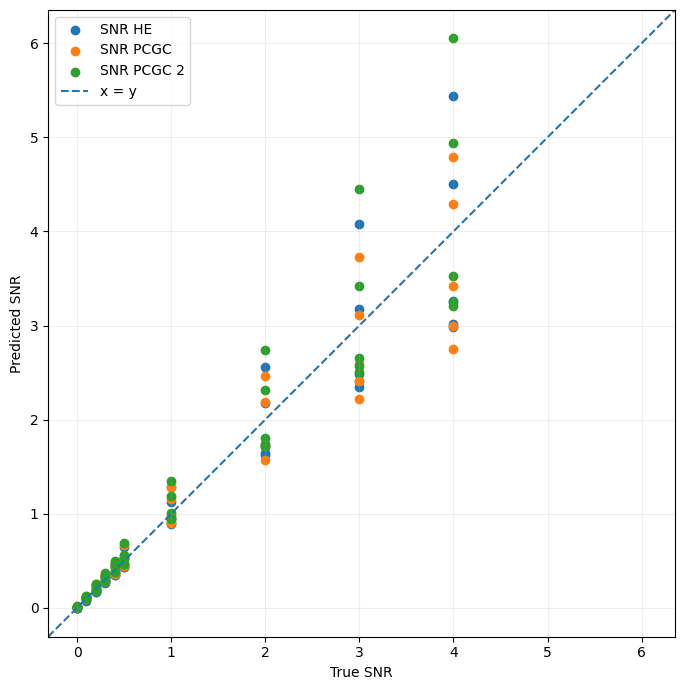

In [94]:
import numpy as np
import matplotlib.pyplot as plt

snr_true = [x[0] for x in results]
snr_he = [x[1] for x in results]
snr_pcgc = [x[2] for x in results]
snr_pcgc2 = [x[3] for x in results]

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(snr_true, snr_he, label="SNR HE")
ax.scatter(snr_true, snr_pcgc, label="SNR PCGC")
ax.scatter(snr_true, snr_pcgc2, label="SNR PCGC 2")

# Wspólny zakres dla X i Y
all_values = np.concatenate([
    np.asarray(snr_true),
    np.asarray(snr_he),
    np.asarray(snr_pcgc),
    np.asarray(snr_pcgc2)
])

vmin = np.nanmin(all_values)
vmax = np.nanmax(all_values)

# opcjonalny margines
margin = 0.05 * (vmax - vmin)
vmin -= margin
vmax += margin

ax.set_xlim(vmin, vmax)
ax.set_ylim(vmin, vmax)

# linia x = y
ax.plot(
    [vmin, vmax],
    [vmin, vmax],
    linestyle="--",
    label="x = y"
)

# identyczna skala jednostek na obu osiach
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("True SNR")
ax.set_ylabel("Predicted SNR")

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

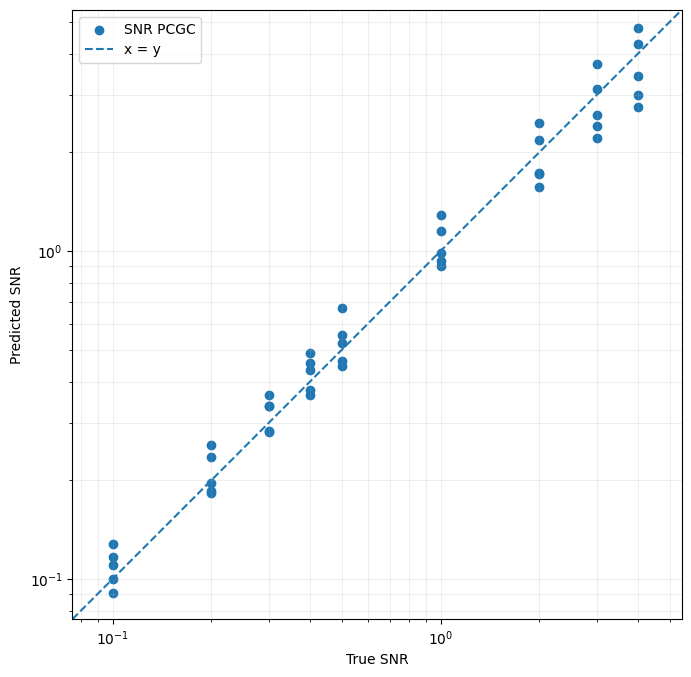

In [93]:
import numpy as np
import matplotlib.pyplot as plt

snr_true = np.asarray([x[0] for x in results])
snr_he = np.asarray([x[1] for x in results])
snr_pcgc = np.asarray([x[2] for x in results])

# pomijamy punkty z zerowym / niedodatnim SNR
mask = (
    (snr_true > 0) &
    (snr_he > 0) &
    (snr_pcgc > 0)
)

x = snr_true[mask]
y_he = snr_he[mask]
y_pcgc = snr_pcgc[mask]

fig, ax = plt.subplots(figsize=(7, 7))

#ax.scatter(x, y_he, label="SNR HE")
ax.scatter(x, y_pcgc, label="SNR PCGC")

# logarytmiczna skala
ax.set_xscale("log")
ax.set_yscale("log")

# wspólny zakres osi
all_values = np.concatenate([x, y_he, y_pcgc])

vmin = np.min(all_values)
vmax = np.max(all_values)

ax.set_xlim(vmin, vmax)
ax.set_ylim(vmin, vmax)

# x = y
ax.plot(
    [vmin, vmax],
    [vmin, vmax],
    "--",
    label="x = y"
)

# identyczna skala fizyczna obu osi
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("True SNR")
ax.set_ylabel("Predicted SNR")

ax.legend()
ax.grid(alpha=0.2, which="both")

plt.tight_layout()
plt.show()

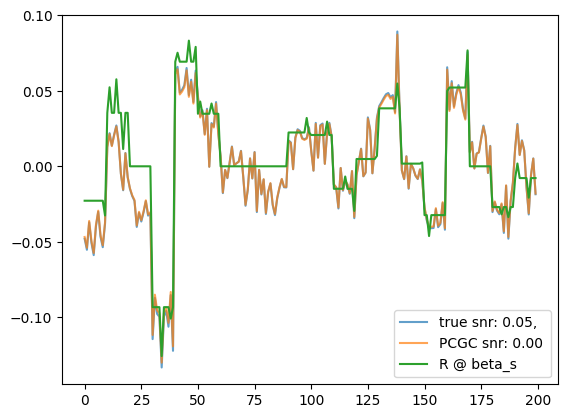

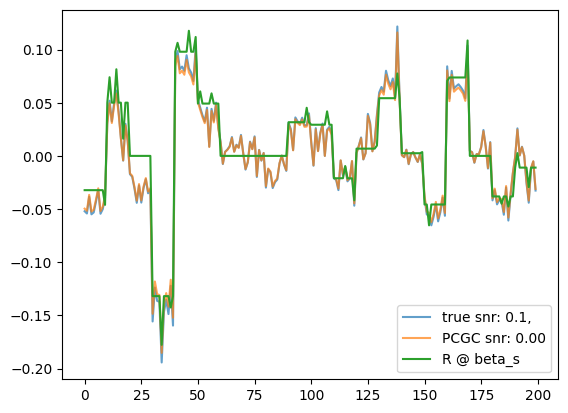

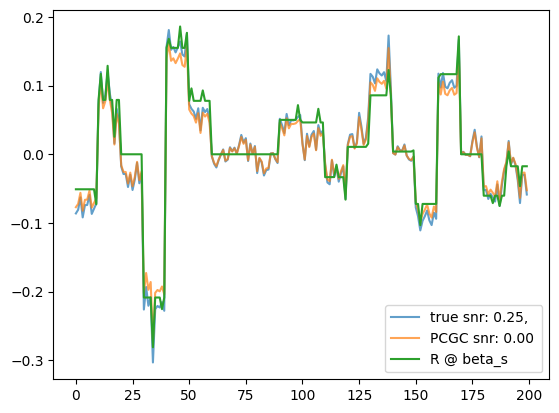

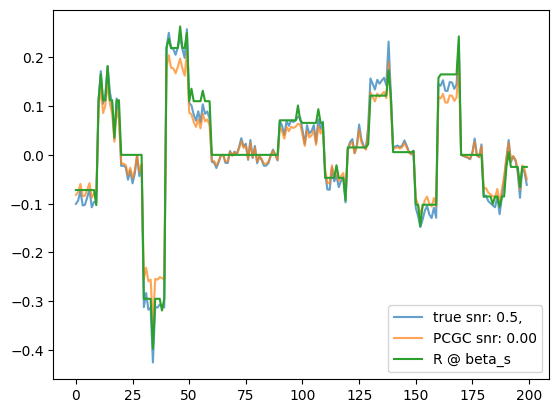

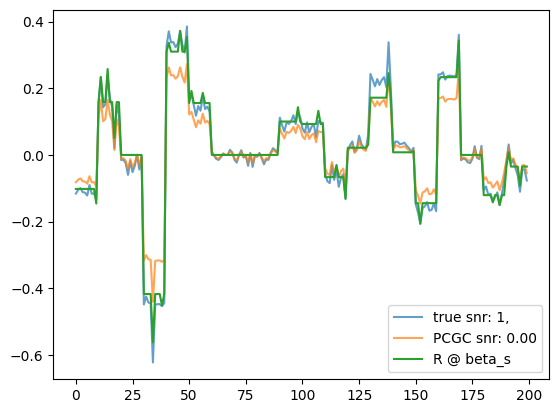

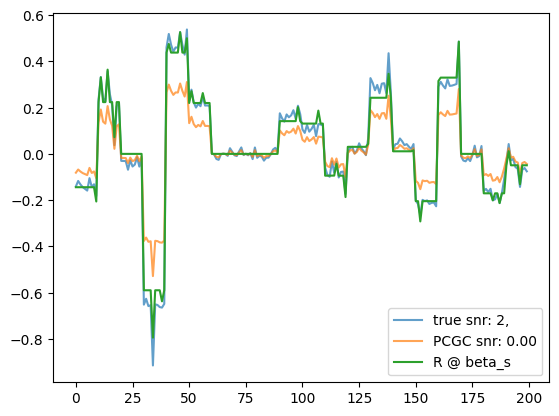

In [90]:
import matplotlib.pyplot as plt

from scipy.stats import norm

def n_eff_probit(n, p_sel):
    """
    Effective sample size for a probit-model SNP effect, derived from the
    Fisher information of the probit likelihood evaluated under H0: beta=0,
    for a standardized predictor (Var(x)=1).
    """
    mu = norm.ppf(p_sel)
    weight = norm.pdf(mu)**2 / (norm.cdf(mu) * (1 - norm.cdf(mu)))
    return n * weight


snr_s = [0.05, 0.1, 0.25, 0.5, 1, 2]

for snr in snr_s:
    
    rng = np.random.default_rng(22)
    
    beta_s = sim.beta_s(d, R, pi_s, snr, rng)
    
    s, y, s_star, y_star =  sim.heckman_outcome(X, beta_s, beta_y, sigma2_y, p_sel, rho, snr, rng = rng)
    
    z_s, a_s = gwas_probit(X, s)[0:2] 

    #z, w = z_scores_no_ascertainment(X, s)

    n_eff = n_eff_probit(n, p_sel)
    latent_sd_correction = np.sqrt(1 + snr)
    
    b_s_corrected = a_s * latent_sd_correction

    h2_pcgc = pcgc_h2_liability(b_s_corrected, R, n, p_sel)
    snr_pcgc = h2_to_snr(h2_pcgc)

    plt.plot(a_s * np.sqrt(snr +1), label = f"true snr: {snr},  ", alpha = 0.7)
    plt.plot(a_s * np.sqrt(snr_pcgc +1), label = f"PCGC snr: {snr_pcgc:.2f}", alpha = 0.7)
    plt.plot(R @ beta_s, label = "R @ beta_s")
    plt.legend()
    plt.show()

In [23]:
import numpy as np

def estimate_h2_obs_HE(X, s):
    """
    Estimate heritability on the observed (0/1) scale using
    Haseman-Elston regression (method of moments).

    Regresses cross-products of phenotype deviations on
    off-diagonal entries of the genomic relationship matrix (GRM).
    """
    n, d = X.shape

    # Genomic relationship matrix (GRM), standard GCTA-style normalization
    GRM = (X @ X.T) / d

    s_c = s - s.mean()  # center phenotype
    y_outer = np.outer(s_c, s_c)  # cross-products (s_i - s_bar)(s_j - s_bar)

    # Use only off-diagonal elements (diagonal carries residual variance too)
    iu = np.triu_indices(n, k=1)
    y_vec = y_outer[iu]
    x_vec = GRM[iu]

    # Simple OLS: y_vec = h2_obs * x_vec + intercept
    X_design = np.column_stack([x_vec, np.ones_like(x_vec)])
    coef, *_ = np.linalg.lstsq(X_design, y_vec, rcond=None)
    h2_obs = coef[0] / s.var()  # normalize by phenotypic variance

    return h2_obs

def obs_to_liability_h2(h2_obs, K):
    """
    Convert heritability from the observed (0/1) scale to the
    liability scale (Falconer-Dodge transformation), assuming
    the sample is a random draw from the population (no ascertainment,
    i.e. sample prevalence P == population prevalence K).
    """
    t = norm.ppf(1 - K)          # liability threshold
    z = norm.pdf(t)               # density at threshold
    return h2_obs * K * (1 - K) / z**2



def h2_to_snr(h2_liability):
    """
    Recover SNR_s from liability-scale heritability.
    Inverse of h2 = SNR / (1 + SNR).
    """
    return h2_liability / (1 - h2_liability)

In [30]:
import numpy as np
from scipy.stats import norm


def pcgc_h2_liability(z_scores, R, n, K):
    """
    Estimate SNP-based heritability on the liability scale using PCGC-s
    (Weissbrod, Flint, Rosset 2018, AJHG), assuming no covariates and
    no ascertainment bias (i.e. sample case fraction P equals population
    prevalence K).

    Parameters
    ----------
    z_scores : array-like, shape (m,)
        GWAS Z-scores from a probit regression, one per SNP.
    R : array-like, shape (m, m)
        LD correlation matrix between the m SNPs (in-sample or from an
        external reference panel; standardized genotype correlations).
    n : int
        Sample size (number of individuals).
    K : float
        Population prevalence of the trait (0 < K < 1).

    Returns
    -------
    h2 : float
        Estimated SNP-based heritability on the liability scale.
    """
    z = np.asarray(z_scores, dtype=float)
    R = np.asarray(R, dtype=float)
    m = z.shape[0]

    if R.shape != (m, m):
        raise ValueError("R must be an (m, m) matrix matching len(z_scores)")

    # Liability threshold corresponding to prevalence K
    tau = norm.ppf(1.0 - K)
    phi_tau = norm.pdf(tau)

    # Normalizing constant f(t,t); since P = K (no ascertainment bias),
    # the case-control correction term K(1-K)/(P(1-P)) cancels to 1,
    # leaving the standard liability-scale conversion factor.
    f_tt = (phi_tau ** 2) / (K * (1.0 - K))

    # Numerator: mean squared Z-score across SNPs (no overlapping-sample
    # correction term, since there is only one study / no genetic
    # correlation term here)
    numerator = np.mean(z ** 2)

    # Denominator: n/m^2 * sum_{k,h} r_kh^2 (Frobenius norm squared of R)
    ld_term = np.sum(R ** 2)
    denominator = (n / m ** 2) * ld_term

    h2_obs_scale = numerator / denominator

    # Convert to liability scale using f(t,t)
    h2 = h2_obs_scale / f_tt

    return h2